In [16]:
from rigol_wave import WaveParser
import numpy as np
import matplotlib.pyplot as plt

parser = WaveParser({"verbose": False})
parser.parse("RigolDS1.bin")
sample_period = parser.waveforms[0]['header'].x_increment
an, ap, clk, frame_start = [wfm['data'] for wfm in parser.waveforms]
analog = ap - an

Opening "RigolDS1.bin"


In [17]:

# find the lines by the absence of the clock
clk_thresholded =  (clk > (3.3 / 2))
last_high = 0
seperators = []
for i, sample in enumerate(clk_thresholded):
    if sample:
        run_length = i - last_high
        if run_length > 50:
            seperators.append((last_high + 1))
        last_high = i

len(seperators)

2795

In [18]:

# do some analysis of the lines
lines = []
for j, (start, end) in enumerate(zip(seperators, seperators[1:])):
    last = False
    count = 0
    start_of_current_clock = 0
    line = []
    for i, sample in enumerate(clk_thresholded[start:end]):
        if not last and sample:  # rising edge
            px_value = np.min(analog[start+start_of_current_clock:start+i])
            line.append(px_value)
            count += 1
            start_of_current_clock = i
        last = sample
    lines.append(line)

    if False:
        x = np.arange((end - start) * sample_period, step=sample_period)
        plt.scatter(x, (clk_thresholded[start:end] - 0.5) / 2)
        plt.scatter(x, analog[start:end])
        plt.show()


Using matplotlib backend: module://matplotlib_inline.backend_inline


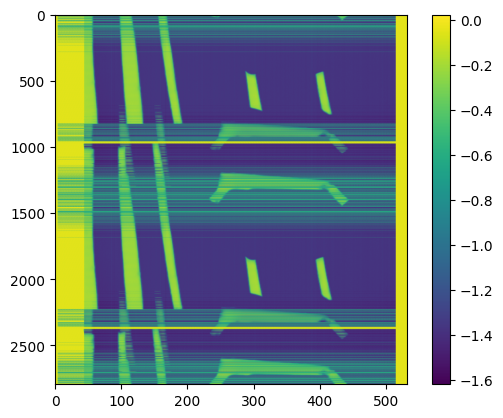

In [19]:
%matplotlib
max_length = max(len(line) for line in lines)
for line in lines:
    while len(line) < max_length:
        line.append(0)
image = np.array(lines)
plt.imshow(image, aspect=0.2)
plt.colorbar()
plt.show()